In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

df = pd.read_csv('creditcard.csv')

X = df.drop(columns=['Class', 'Time'], errors = 'ignore')
if 'account_id' in X.columns:
    X = df.drop(columns=['account_id'])

y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)
print(f"Training Set: {X_train.shape[0]} rows (Frauds: {y_train.sum()})")
print(f"Test Set: {X_test.shape[0]} rows (Frauds: {y_test.sum()})")



Training Set: 227845 rows (Frauds: 394)
Test Set: 56962 rows (Frauds: 98)


In [5]:
smote = SMOTE(random_state = 42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE training target distribution: {y_train.value_counts().to_dict()}")
print(f"After SMOTE training target distribution: {pd.Series(y_train_res).value_counts().to_dict()}")

Before SMOTE training target distribution: {0: 227451, 1: 394}
After SMOTE training target distribution: {0: 227451, 1: 227451}


In [6]:
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42, n_jobs = -1)
rf_model.fit(X_train_res, y_train_res)

y_probs = rf_model.predict_proba(X_test)[:, 1]
print("Model training complete!")

Model training complete!


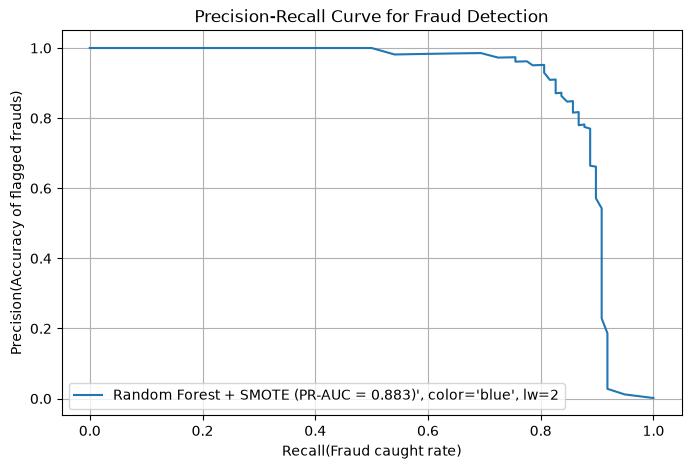

PR-AUC Score: 0.8826


In [7]:
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
pr_auc = average_precision_score(y_test, y_probs)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f"Random Forest + SMOTE (PR-AUC = {pr_auc:.3f})', color='blue', lw=2")
plt.xlabel("Recall(Fraud caught rate)")
plt.ylabel("Precision(Accuracy of flagged frauds)")
plt.title('Precision-Recall Curve for Fraud Detection')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

print(f"PR-AUC Score: {pr_auc:.4f}")

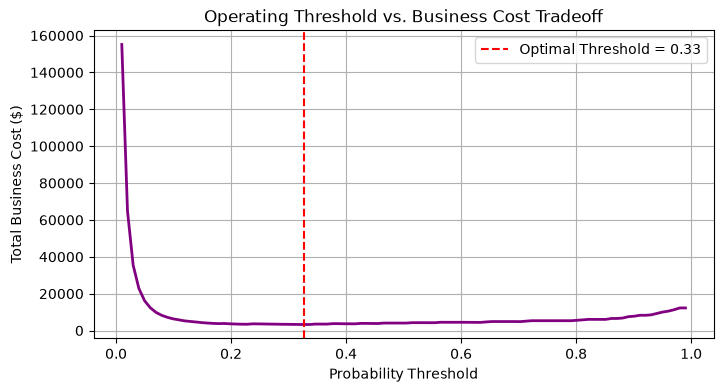

Optimal Threshold: 0.33
Minimum Total Expected Business Cost: $3,270.00

--- Final Performance at Optimal Threshold ---
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.77      0.89      0.82        98

    accuracy                           1.00     56962
   macro avg       0.88      0.94      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [8]:
cost_fp = 20
cost_fn = 250   

best_threshold = 0.5
min_total_cost = float('inf')
cost_history = []

test_thresholds = np.linspace(0.01, 0.99, 100)
for t in test_thresholds:
    preds = (y_probs >= t).astype(int)
    cm = confusion_matrix(y_test, preds)
    fp = cm[0][1]
    fn = cm[1][0]

    total_cost = (fp * cost_fp) + (fn * cost_fn)
    cost_history.append(total_cost)

    if total_cost<min_total_cost:
        min_total_cost = total_cost
        best_threshold = t
plt.figure(figsize=(8, 4))
plt.plot(test_thresholds, cost_history, color='purple', lw=2)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Optimal Threshold = {best_threshold:.2f}')
plt.xlabel('Probability Threshold')
plt.ylabel('Total Business Cost ($)')
plt.title('Operating Threshold vs. Business Cost Tradeoff')
plt.legend()
plt.grid(True)
plt.show()

print(f"Optimal Threshold: {best_threshold:.2f}")
print(f"Minimum Total Expected Business Cost: ${min_total_cost:,.2f}")

# Final Classification Report at Optimal Threshold
final_preds = (y_probs >= best_threshold).astype(int)
print("\n--- Final Performance at Optimal Threshold ---")
print(classification_report(y_test, final_preds, target_names=['Normal', 'Fraud']))